In [1]:
# Cell 1: FASTA loader and one‑hot encoder (optimized for Kaggle)
import numpy as np
import time

def load_and_encode_fasta(fasta_path, label):
    """
    Load FASTA file, uppercase sequences, convert to one‑hot tensor.
    
    Args:
        fasta_path: Path to cleaned FASTA file
        label: Integer label for all sequences (1=positive, 0=negative)
    
    Returns:
        onehot: (n_samples, 101, 4) int8 array
        labels: (n_samples,) int8 array
    """
    start = time.time()
    sequences = []
    
    with open(fasta_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('>'):
                sequences.append(line.upper())
    
    n_samples = len(sequences)
    seq_array = np.array([list(seq) for seq in sequences], dtype='U1')
    
    # One‑hot encoding (vectorized per‑channel)
    onehot = np.zeros((n_samples, 101, 4), dtype=np.int8)
    onehot[seq_array == 'A', 0] = 1
    onehot[seq_array == 'C', 1] = 1
    onehot[seq_array == 'G', 2] = 1
    onehot[seq_array == 'T', 3] = 1
    
    labels = np.full(n_samples, label, dtype=np.int8)
    
    elapsed = time.time() - start
    print(f"Loaded label={label}: {n_samples} samples in {elapsed:.2f}s")
    return onehot, labels

In [3]:
# Cell 2: Load data and stratified split
from sklearn.model_selection import train_test_split

# Update this path to match your Kaggle Dataset name
DATA_DIR = "/kaggle/input/datasets/letinyz/sp1-cleaned-datasets"

pos_path = f"{DATA_DIR}/sp1_positive_101bp_clean.fasta"
neg_path = f"{DATA_DIR}/sp1_negative_101bp_clean.fasta"

print("Loading positive samples (label=1)...")
X_pos, y_pos = load_and_encode_fasta(pos_path, label=1)

print("Loading negative samples (label=0)...")
X_neg, y_neg = load_and_encode_fasta(neg_path, label=0)

# Merge and split
X = np.concatenate([X_pos, X_neg], axis=0)
y = np.concatenate([y_pos, y_neg], axis=0)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("\n=== Dataset Summary ===")
print(f"X_train: {X_train.shape}, y_train dist: {np.bincount(y_train)}")
print(f"X_val:   {X_val.shape}, y_val dist:   {np.bincount(y_val)}")

Loading positive samples (label=1)...
Loaded label=1: 24540 samples in 0.48s
Loading negative samples (label=0)...
Loaded label=0: 23316 samples in 0.45s

=== Dataset Summary ===
X_train: (38284, 101, 4), y_train dist: [18652 19632]
X_val:   (9572, 101, 4), y_val dist:   [4664 4908]


In [4]:
# Cell 3: DeepBind‑style 1D‑CNN
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout

def build_cnn(seq_len=101, channels=4):
    model = Sequential([
        Conv1D(filters=64, kernel_size=15, activation='relu',
               input_shape=(seq_len, channels), name='motif_scanner'),
        GlobalMaxPooling1D(name='position_invariance_pool'),
        Dense(32, activation='relu', name='fc1'),
        Dropout(0.5, name='dropout'),
        Dense(1, activation='sigmoid', name='output')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

model = build_cnn()
model.summary()

2026-04-12 11:50:13.193659: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775994613.463113      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775994613.534686      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775994614.154253      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775994614.154304      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775994614.154309      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ motif_scanner (Conv1D)          │ (None, 87, 64)         │         3,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ position_invariance_pool        │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,017 (23.50 KB)

 Trainable params: 6,017 (23.50 KB)

 Non-trainable params: 0 (0.00 B)


=== Training CNN ===
Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8025 - auc: 0.8724 - loss: 0.4458 - val_accuracy: 0.8806 - val_auc: 0.9492 - val_loss: 0.2897
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8855 - auc: 0.9440 - loss: 0.3024 - val_accuracy: 0.8889 - val_auc: 0.9533 - val_loss: 0.2757
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8958 - auc: 0.9534 - loss: 0.2756 - val_accuracy: 0.8877 - val_auc: 0.9552 - val_loss: 0.2741
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9001 - auc: 0.9551 - loss: 0.2704 - val_accuracy: 0.8905 - val_auc: 0.9566 - val_loss: 0.2689
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9013 - auc: 0.9576 - loss: 0.2627 - val_accuracy: 0.8928 - val_auc: 0.9572 - val_loss: 0.2620
Epoch 6/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9049 - auc: 0.9599 - loss: 0.2563 - val_accuracy: 0.8926 - val_auc: 0.9576 - val_loss: 0.2623
Epoch 7/15
3

Model saved to /kaggle/working/sp1_cnn_model.h5


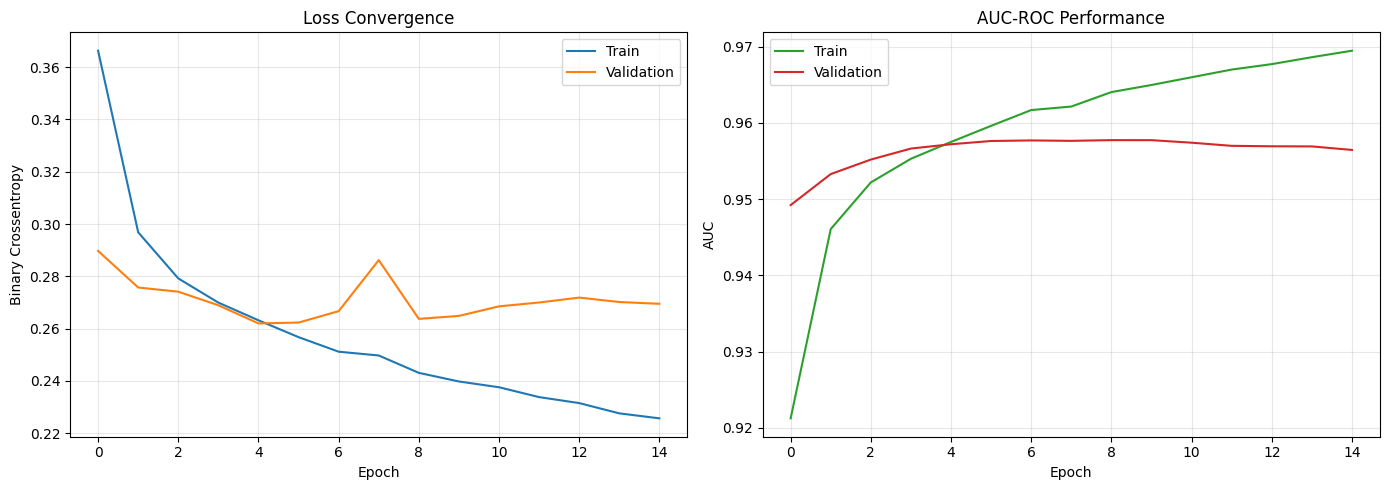


Final Validation AUC: 0.9564


In [5]:
# Cell 4: Train and visualize
import matplotlib.pyplot as plt

# Enable Kaggle GPU before running this cell
print("\n=== Training CNN ===")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    verbose=1
)

# Save model
model.save('/kaggle/working/sp1_cnn_model.h5')
print("Model saved to /kaggle/working/sp1_cnn_model.h5")

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train', color='#1f77b4')
ax1.plot(history.history['val_loss'], label='Validation', color='#ff7f0e')
ax1.set_title('Loss Convergence')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Crossentropy')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history.history['auc'], label='Train', color='#2ca02c')
ax2.plot(history.history['val_auc'], label='Validation', color='#d62728')
ax2.set_title('AUC‑ROC Performance')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('AUC')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

# Print final metrics
final_auc = history.history['val_auc'][-1]
print(f"\nFinal Validation AUC: {final_auc:.4f}")